In [3]:
import json, re


def _segs_from_html(html_path):
    """Read the `segs` list that audiovisualize_interactive() writes into the HTML."""
    with open(html_path, encoding="utf-8") as f:
        html = f.read()
    m = re.search(r"const segs=(\[.*?\]), env=", html, re.S)
    if m is None:
        raise ValueError(f"no `segs` data found in {html_path}")
    return json.loads(m.group(1))


def phonemes_per_second(source, pause_kinds=("space", "punct")):
    """Phonemes per second for every sentence (= every BOS ... EOS chunk).

    source : path to an HTML file made by audiovisualize_interactive(), OR the
             `segments` list returned by synth_aligned() (tuples or dicts).

    Only tokens of kind 'phone' are counted; stress marks, diacritics,
    punctuation, spaces and BOS/EOS are not.

    Two rates are returned per sentence:
      speech_rate       = n_phonemes / time from end of BOS to start of EOS
                          (includes the short gaps between words and pauses
                          at commas)
      articulation_rate = n_phonemes / same time minus the `pause_kinds`
                          tokens (only the time spent actually sounding words)

    Returns a list of dicts, one per sentence, in order.
    """
    if isinstance(source, str):
        segs = _segs_from_html(source)
    else:  # segments from synth_aligned(): (tok, start, end, info)
        segs = []
        for seg in source:
            tok, s, e = seg[:3]
            info = seg[3] if len(seg) > 3 and isinstance(seg[3], dict) else {}
            segs.append({"t": tok, "s": s, "e": e, "k": info.get("kind", "phone")})

    sentences, cur = [], None
    for g in segs:
        kind = g["k"]
        if kind == "bos":
            cur = {"start": g["e"], "phones": 0, "pause": 0.0, "words": []}
        elif kind == "eos":
            if cur is None:
                continue
            span = g["s"] - cur["start"]
            speak = span - cur["pause"]
            sentences.append({
                "sentence":          len(sentences) + 1,
                "text":              " ".join(cur["words"]),
                "start_s":           round(cur["start"], 3),
                "end_s":             round(g["s"], 3),
                "duration_s":        round(span, 3),
                "n_phonemes":        cur["phones"],
                "speech_rate":       round(cur["phones"] / span, 2) if span > 0 else None,
                "articulation_rate": round(cur["phones"] / speak, 2) if speak > 0 else None,
            })
            cur = None
        elif cur is not None:
            dur = g["e"] - g["s"]
            if kind == "phone":
                cur["phones"] += 1
            elif kind in pause_kinds:
                cur["pause"] += dur
            wl = g.get("wl")
            if wl and (not cur["words"] or cur.get("_w") != g.get("w")):
                cur["words"].append(wl)
                cur["_w"] = g.get("w")
    return sentences

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------- load
def load_rates(html_path, rate="articulation_rate", k=2.0):
    """Load one HTML file -> DataFrame with one row per sentence + outlier flags.

    rate : "articulation_rate" (pauses removed) or "speech_rate"
    k    : outlier threshold (z-score > k, and 1.5*IQR rule)
    """
    df = pd.DataFrame(phonemes_per_second(html_path))
    df["rate"] = df[rate]
    df["z"] = (df["rate"] - df["rate"].mean()) / df["rate"].std(ddof=0)
    q1, q3 = df["rate"].quantile([.25, .75])
    iqr = q3 - q1
    df["iqr_out"] = (df["rate"] < q1 - 1.5 * iqr) | (df["rate"] > q3 + 1.5 * iqr)
    df["outlier"] = np.where(df["z"] > k, "fast", np.where(df["z"] < -k, "slow", ""))
    return df


# load html 



# ---------------------------------------------------------------- plots
COL = {"": "#6b7280", "fast": "#dc2626", "slow": "#2563eb"}

def plot_bars(df, k=2.0):
    """1) One bar per sentence, mean +/- k*SD band. Best for 'which sentence?'"""
    m, s = df["rate"].mean(), df["rate"].std(ddof=0)
    fig, ax = plt.subplots(figsize=(max(8, len(df) * .35), 4))
    ax.bar(df["sentence"], df["rate"], color=[COL[o] for o in df["outlier"]])
    ax.axhline(m, color="k", lw=1)
    ax.axhspan(m - k * s, m + k * s, color="gray", alpha=.15, label=f"mean ± {k} SD")
    for _, r in df[df["outlier"] != ""].iterrows():
        ax.annotate(int(r["sentence"]), (r["sentence"], r["rate"]), ha="center", va="bottom", fontsize=8)
    ax.set(xlabel="sentence", ylabel="phonemes / s", title="Rate per sentence (red = fast, blue = slow)")
    ax.legend(); plt.tight_layout(); return fig

def plot_box(df):
    """2) Box plot + points. Best for the overall spread and IQR outliers."""
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.boxplot(df["rate"], widths=.5, showfliers=False)
    x = np.random.default_rng(0).normal(1, .04, len(df))
    ax.scatter(x, df["rate"], c=[COL[o] for o in df["outlier"]], s=25, zorder=3)
    for xi, (_, r) in zip(x, df[df["iqr_out"]].iterrows()):
        ax.annotate(int(r["sentence"]), (1.08, r["rate"]), fontsize=8)
    ax.set(xticks=[], ylabel="phonemes / s", title="Distribution")
    plt.tight_layout(); return fig

def plot_hist(df, k=2.0):
    """3) Histogram with mean +/- k*SD lines. Best for judging the distribution shape."""
    m, s = df["rate"].mean(), df["rate"].std(ddof=0)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df["rate"], bins="auto", color="#9ca3af", edgecolor="w")
    for v in (m - k * s, m, m + k * s):
        ax.axvline(v, color="k", ls="--" if v != m else "-", lw=1)
    ax.set(xlabel="phonemes / s", ylabel="# sentences", title="Histogram")
    plt.tight_layout(); return fig

def plot_timeline(df):
    """4) Rate along the story's time axis. Best for spotting slow/fast *regions*."""
    fig, ax = plt.subplots(figsize=(10, 3.5))
    mid = (df["start_s"] + df["end_s"]) / 2
    ax.plot(mid, df["rate"], color="#9ca3af", lw=1)
    ax.scatter(mid, df["rate"], c=[COL[o] for o in df["outlier"]], s=30, zorder=3)
    if len(df) >= 5:                                   # smooth trend (rolling mean of 5)
        ax.plot(mid, df["rate"].rolling(5, center=True, min_periods=1).mean(), color="k", lw=2, alpha=.5)
    ax.axhline(df["rate"].mean(), color="k", lw=1, ls=":")
    ax.set(xlabel="time in story (s)", ylabel="phonemes / s", title="Rate over time")
    plt.tight_layout(); return fig

def plot_scatter(df, k=2.0):
    """5) Duration vs #phonemes with a fitted line. Sentences far from the line are
    fast/slow *for their length* (removes the effect of sentence length)."""
    a, b = np.polyfit(df["n_phonemes"], df["duration_s"], 1)
    res = df["duration_s"] - (a * df["n_phonemes"] + b)
    z = res / res.std(ddof=0)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["n_phonemes"], df["duration_s"],
               c=np.where(z > k, "#2563eb", np.where(z < -k, "#dc2626", "#6b7280")), s=30)   # longer than expected = slow
    xs = np.array([df["n_phonemes"].min(), df["n_phonemes"].max()])
    ax.plot(xs, a * xs + b, "k--", lw=1)
    for i in df.index[np.abs(z) > k]:
        ax.annotate(int(df.loc[i, "sentence"]), (df.loc[i, "n_phonemes"], df.loc[i, "duration_s"]), fontsize=8)
    ax.set(xlabel="# phonemes", ylabel="duration (s)", title="Duration vs length (above line = slow)")
    plt.tight_layout(); return fig




In [14]:
path = "output_online\story1__clean_0.8.html"

# df = load_rates(path)              # articulation rate (pauses removed)
df = load_rates(path, rate="speech_rate")      # or include pauses
# df = load_rates("story1.html", k=1.5)                   # stricter/looser outlier threshold

print(df[df["outlier"] != ""])                            # the outlier sentences

    sentence                                              text  start_s  \
8          9  Il sottomarino fu chiamato Freccia delgi Abissi.  112.250   
26        27                            Ma il tempo stringeva.  341.525   

      end_s  duration_s  n_phonemes  speech_rate  articulation_rate  rate  \
8   116.375       4.125          36         8.73              10.00  8.73   
26  343.950       2.425          18         7.42               8.67  7.42   

           z  iqr_out outlier  
8  -2.143799     True    slow  
26 -5.720975     True    slow  


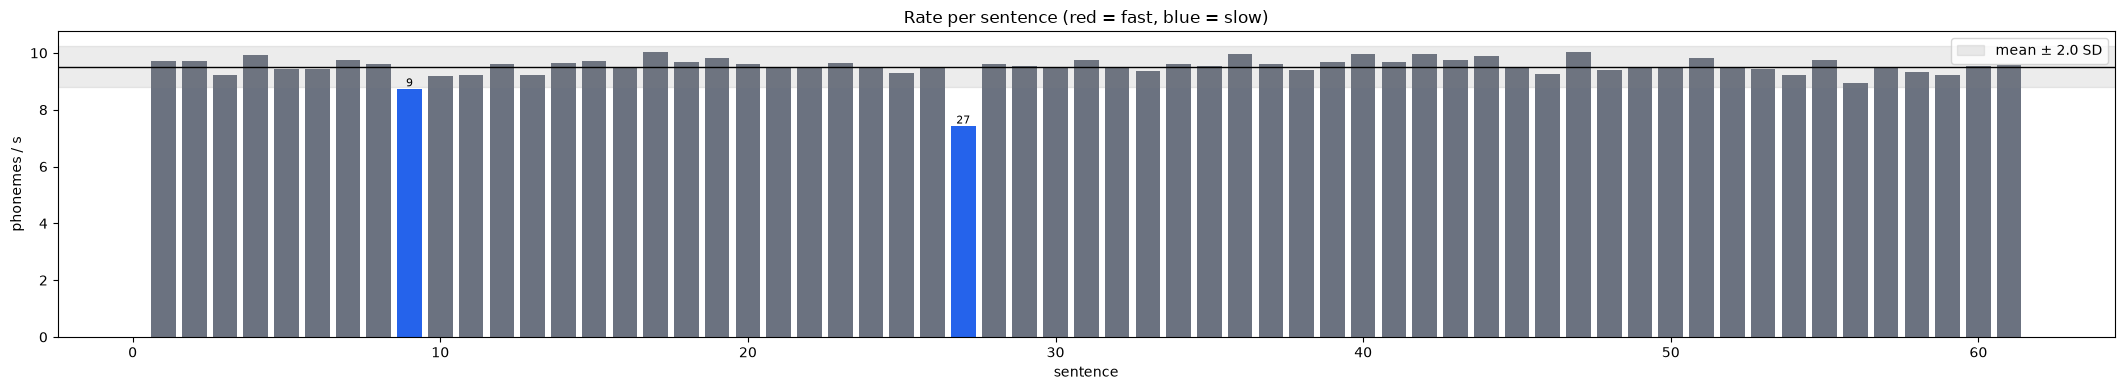

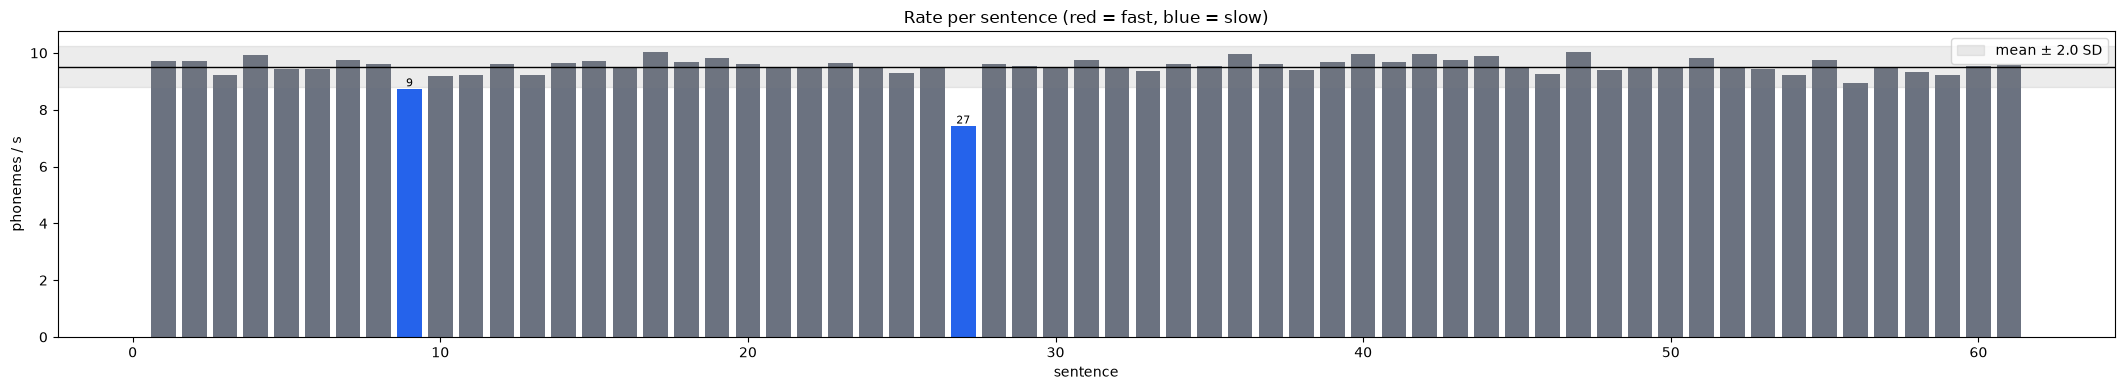

In [15]:
plot_bars(df)

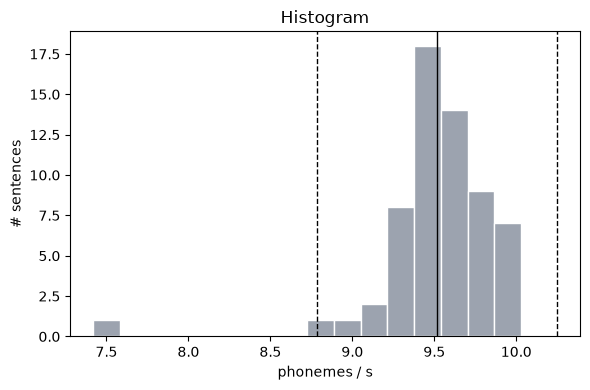

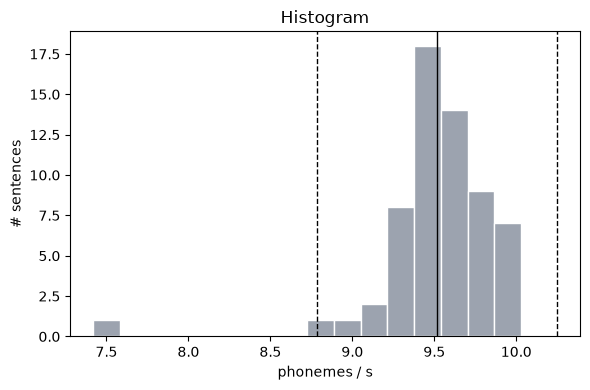

In [16]:
plot_hist(df)

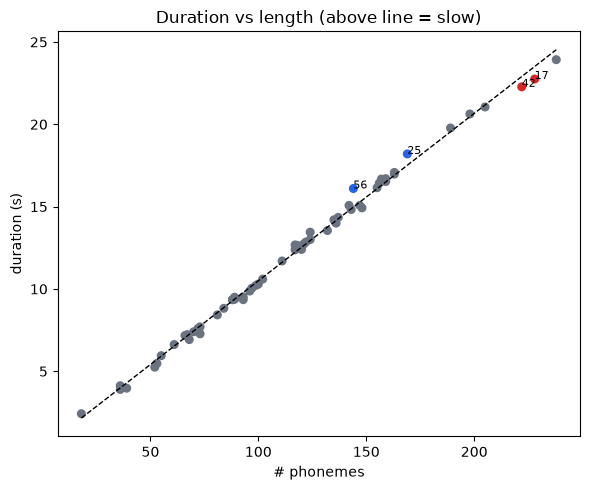

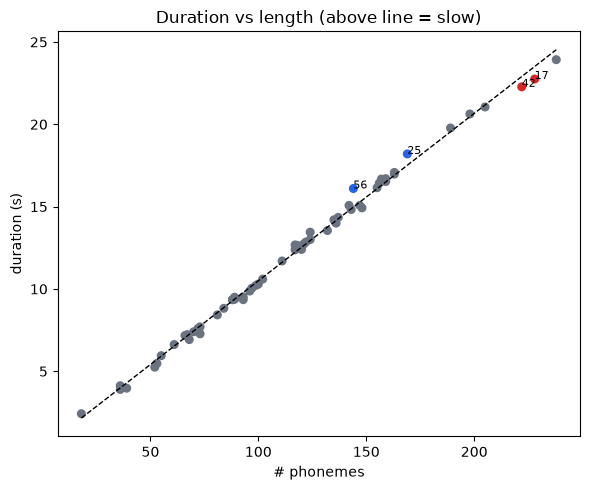

In [18]:
plot_scatter(df)

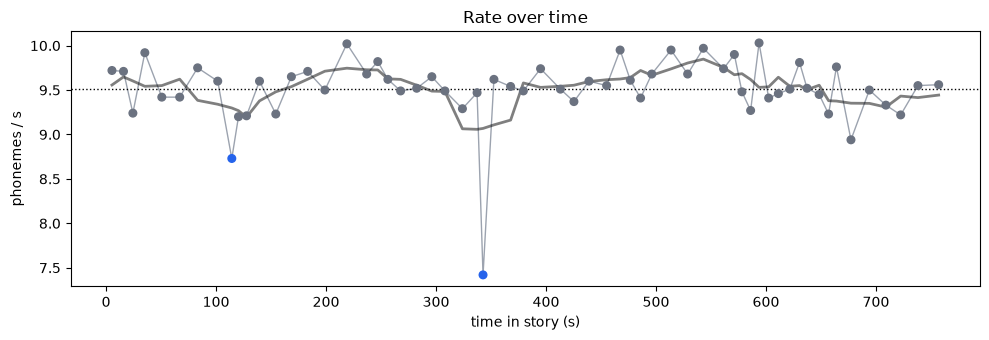

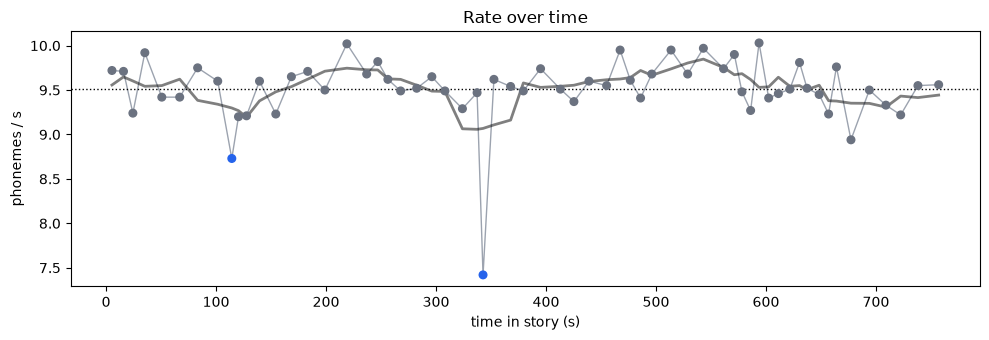

In [17]:
plot_timeline(df)

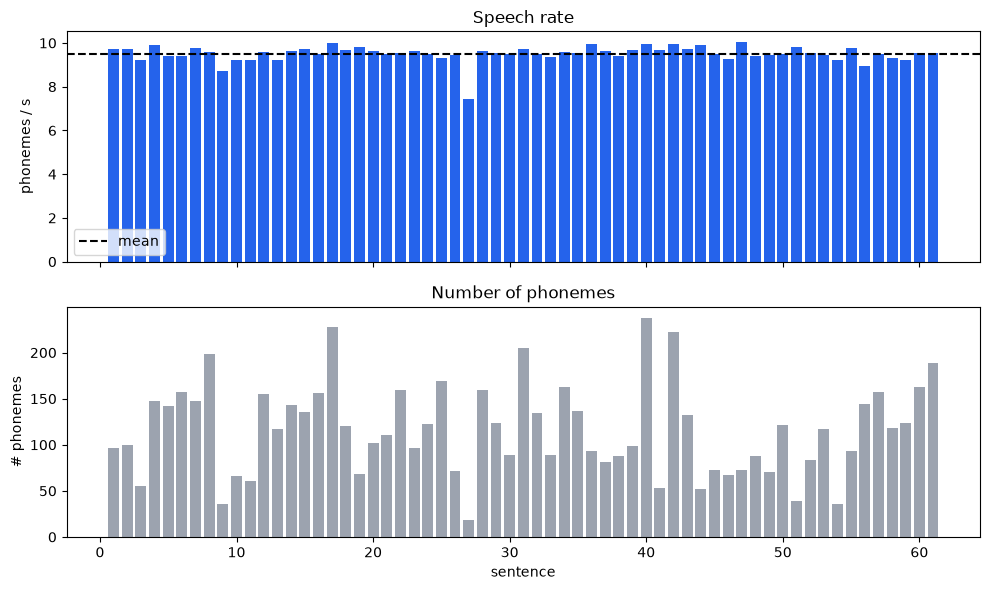

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].bar(df["sentence"], df["speech_rate"], color="#2563eb")
ax[0].axhline(df["speech_rate"].mean(), color="k", ls="--", label="mean")
ax[0].set_ylabel("phonemes / s")
ax[0].set_title("Speech rate")
ax[0].legend()

ax[1].bar(df["sentence"], df["n_phonemes"], color="#9ca3af")
ax[1].set_ylabel("# phonemes")
ax[1].set_xlabel("sentence")
ax[1].set_title("Number of phonemes")

plt.tight_layout()
plt.show()

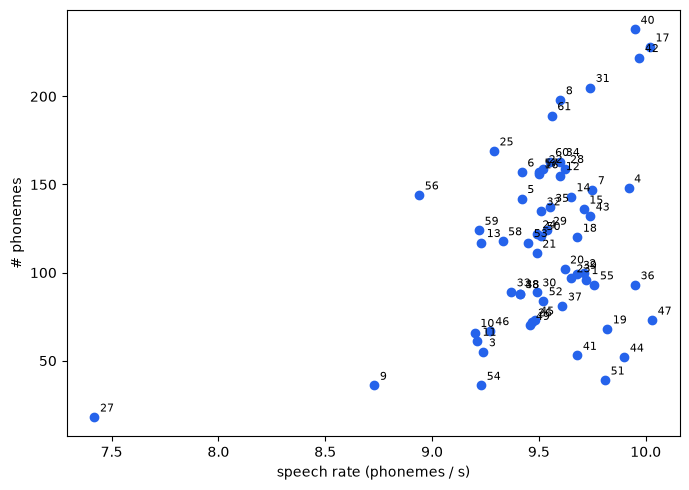

In [20]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["speech_rate"], df["n_phonemes"], color="#2563eb")

for _, r in df.iterrows():
    ax.annotate(int(r["sentence"]), (r["speech_rate"], r["n_phonemes"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel("speech rate (phonemes / s)")
ax.set_ylabel("# phonemes")
plt.tight_layout()
plt.show()

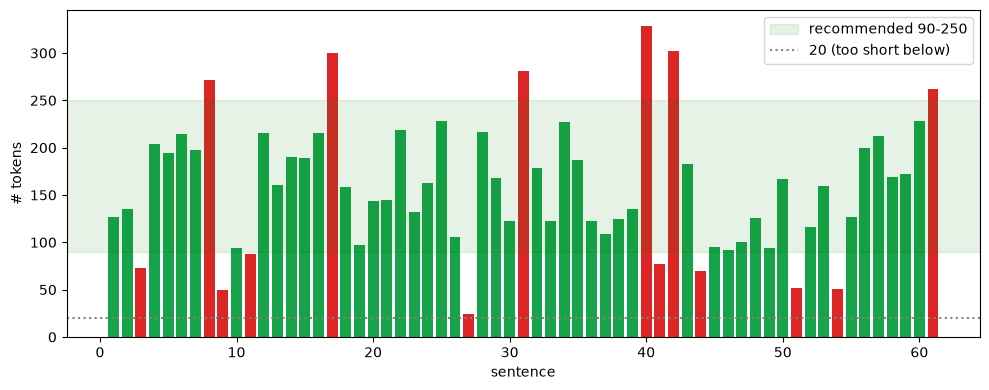

In [24]:
import pandas as pd
import matplotlib.pyplot as plt


segs = _segs_from_html(path)

counts, n = [], 0
for g in segs:
    if g["k"] == "bos":
        n = 0
    elif g["k"] == "eos":
        counts.append(n)
    else:
        n += 1                       # every Kokoro token except BOS/EOS

df = pd.DataFrame({"sentence": range(1, len(counts) + 1), "n_tokens": counts})
    
colors = ["#16a34a" if 90 <= n <= 250 else "#dc2626" for n in df["n_tokens"]]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df["sentence"], df["n_tokens"], color=colors)
ax.axhspan(90, 250, color="green", alpha=0.1, label="recommended 90-250")
ax.axhline(20, color="gray", ls=":", label="20 (too short below)")
ax.set_xlabel("sentence")
ax.set_ylabel("# tokens")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
from smart_chunks import smart_chunks, report
from functions import one_sentence_chunks, VOCAB
import json
import os
os.environ["PHONEMIZER_ESPEAK_LIBRARY"] = r"C:\Program Files\eSpeak NG\libespeak-ng.dll"
os.environ["PHONEMIZER_ESPEAK_PATH"] = r"C:\Program Files\eSpeak NG\espeak-ng.exe"
from kokoro import KPipeline, KModel
import torch
from pathlib import Path
from huggingface_hub import hf_hub_download
import soundfile as sf
from IPython.display import display, Audio
import re, numpy as np

with open("story1.txt", "r", encoding="utf-8") as f:
    text = f.read()

g2p = KPipeline(lang_code="i", model=False)   # espeak-backed Italian G2P, no model
text_chunks, ipa_chunks = smart_chunks(
    text,
    g2p_fn=lambda s: g2p.g2p(s)[0],
    vocab=VOCAB,
    sentence_split=one_sentence_chunks,
    lo=90, hi=250, target=150,
)
report(text_chunks, ipa_chunks, VOCAB)      # check the lengths



  0  127 tok | …lto più complessa di un viaggio nello spazio.
  1  209 tok | …vece, la situazione si ribalta completamente.  <-- outside 100-200
  2  204 tok | …are, il peso dell'acqua diventa schiacciante.  <-- outside 100-200
  3  194 tok | …ualunque oggetto provi a scendere fin laggiù.
  4  214 tok | …olo per pochi minuti prima di dover risalire.  <-- outside 100-200
  5  198 tok | …o il momento di cambiare le regole del gioco.
  6   90 tok | …re un sottomarino sul fondo per pochi minuti;  <-- outside 100-200
  7  180 tok | …più profondi di tutti gli oceani della Terra.
  8  145 tok | …hi sottomarini a forma di pillola o di sfera.
  9   88 tok | …io aeroplano, ma fatto per volare sott'acqua.  <-- outside 100-200
 10  216 tok | …verso il basso, dritto nel cuore dell'oceano.  <-- outside 100-200
 11  161 tok | … e molto pubblicizzato: la fibra di carbonio.
 12  190 tok | …credibilmente resistente quando viene tirato.
 13  189 tok | …arente fatta di un vetro speciale molto puro.
 14  2